# Import

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict
import itertools


# Load Data

In [2]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

In [3]:
df.shape

(231637, 12)

# Data Preprocessing

As shown in Table 1, no null values were removed because the relevant columns are complete. Nulls in the description column merely indicate that a customer chose not to provide feedback and do not affect the analysis. Similarly, that one recipe, which does not have a name, still has a non-empty ingredients and tag list, so it was usable.

In [4]:
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [5]:
# Convert the tags into a list
df["nutrition"] = df["nutrition"].apply(json.loads)

# Convert the tags into
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

# EDA

Across all recipes, salt, butter, and sugar are the most frequently used ingredients, followed by staples like onion, water, eggs, and olive oil. Common items such as flour, milk, garlic, and pepper indicate a reliance on basic seasonings and foundational components. This pattern reflects typical everyday cooking and helps identify core ingredients for meal planning, especially for seniors.

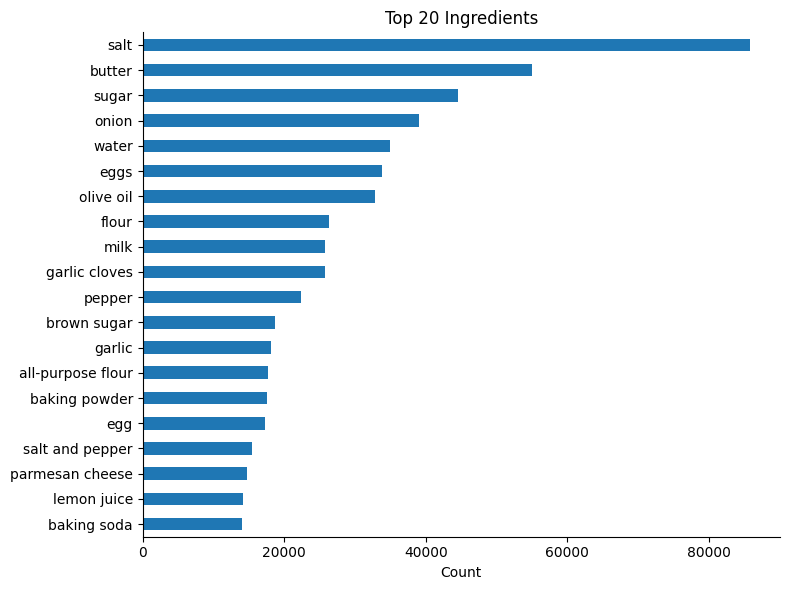

In [6]:
top_ingredients = (
    df["ingredients"]
    .explode()
    .value_counts()[:20]
    .sort_values(ascending=True)
)

ax = top_ingredients.plot(kind="barh", figsize=(8, 6))
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Top 20 Ingredients")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save the figure
plt.tight_layout()
plt.savefig("figures/top_20_ingredients.png", dpi=300)
plt.show()


A food is considered healthy if it has a tag containing the word “health,” which in this dataset corresponds to `healthy` or `healthy-2`. Recipes with at least one such tag are included in the df_healthy subset for analysis. Healthy foods consist 20% of the sample.

In [7]:
# Create the tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(tags_matrix, columns=mlb.classes_, index=df.index)

# Automatically find all tags that contain "health"
health_related_tags = [
    col for col in df_tags_matrix.columns if 'health' in col.lower()
]

# Create a boolean mask for healthy-tagged foods
is_health_tag = df_tags_matrix[health_related_tags].any(axis=1)

# Filter the healthy foods
df_healthy = df[is_health_tag]
df_non_healthy = df[~is_health_tag]

# Save the indices (or IDs) of healthy foods to a CSV file
df_healthy.index.to_series().to_csv(
    'data/is_healthy_food.csv',
    index=False,
    header=False
)

We also check the differences in the distribution of the nutritional values between all the recipes and just the healthy recipes. We see that most of them are similar, except for total_fat_PDV and saturated_fat_PDV. THis makes sense because like...yeahh....

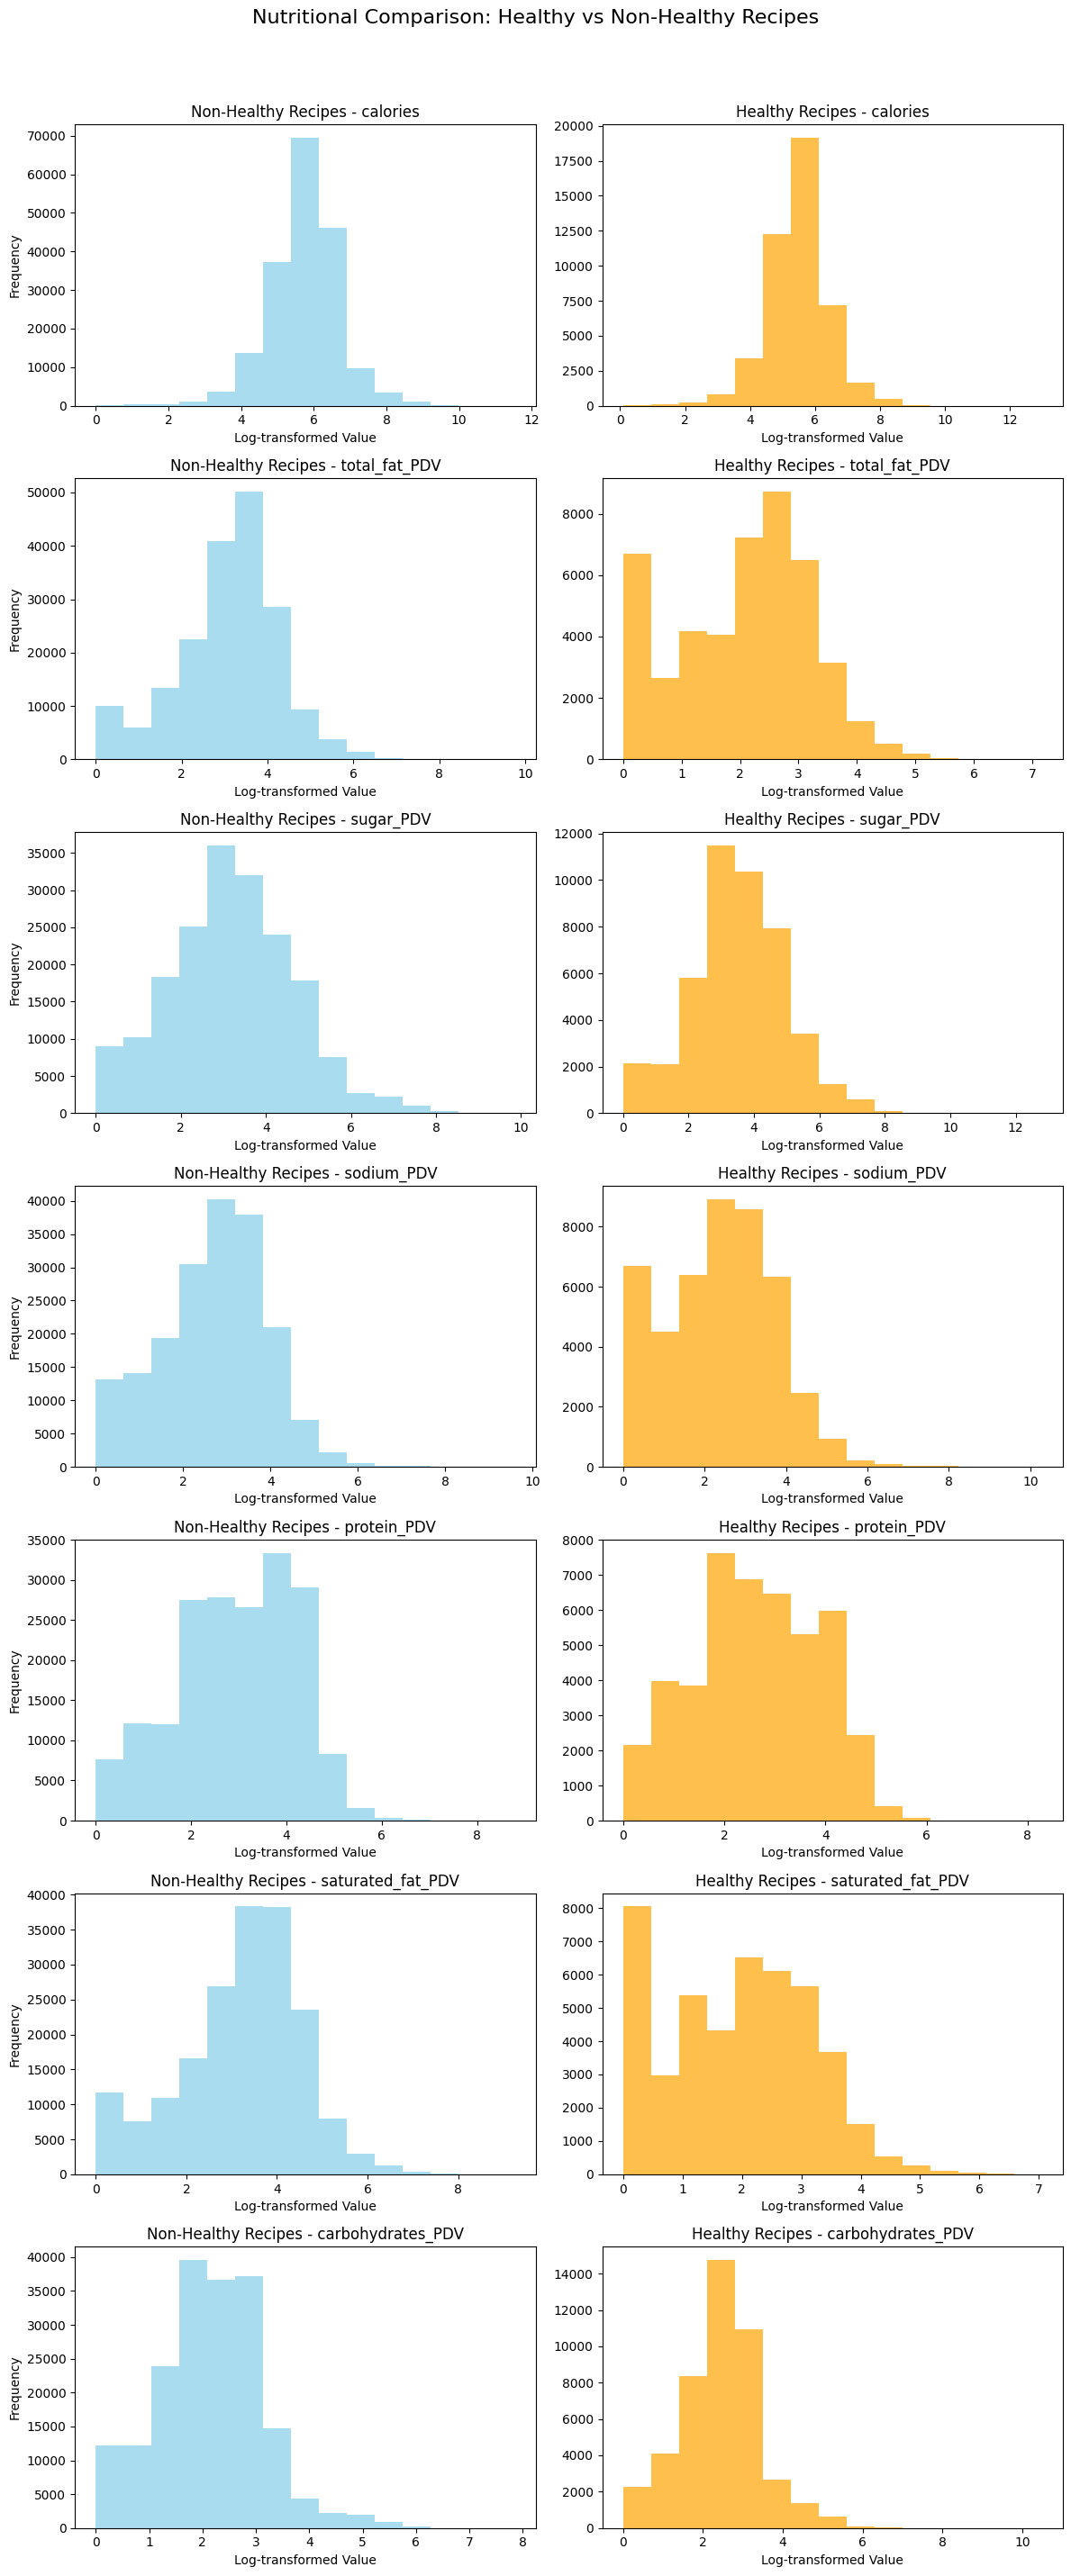

In [8]:
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_healthy_nutritions = df_healthy["nutrition"].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols

df_non_healthy_nutritions = df_non_healthy["nutrition"].apply(pd.Series)
df_non_healthy_nutritions.columns = nutrition_cols

# -------------------------
# Plot comparison
# -------------------------
selected_cols = nutrition_cols

fig, axes = plt.subplots(
    nrows=len(selected_cols),
    ncols=2,
    figsize=(12, 4 * len(selected_cols))
)
fig.suptitle("Nutritional Comparison: Healthy vs Non-Healthy Recipes", fontsize=16, y=1.02)

for i, col in enumerate(selected_cols):
    # Non-healthy recipes
    axes[i, 0].hist(
        np.log1p(df_non_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="skyblue"
    )
    axes[i, 0].set_title(f"Non-Healthy Recipes - {col}")
    axes[i, 0].set_xlabel("Log-transformed Value")
    axes[i, 0].set_ylabel("Frequency")

    # Healthy recipes
    axes[i, 1].hist(
        np.log1p(df_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="orange"
    )
    axes[i, 1].set_title(f"Healthy Recipes - {col}")
    axes[i, 1].set_xlabel("Log-transformed Value")

plt.tight_layout()
plt.show()


# Results and Discussion

## FIM all ingredients for only Non-Healthy food


### Hyperparameter tuning

In [9]:
# --- Prepare transactions (list of ingredient lists) ---
transactions = df_non_healthy['ingredients'].tolist()

# --- Set minimum support threshold ---
min_support = 0.001  # you can adjust this

# --- Compute absolute minimum support count ---
minsup_count = max(1, int(len(transactions) * min_support))

# --- Find frequent itemsets ---
patterns = pyfpgrowth.find_frequent_patterns(transactions, 
                                             minsup_count)

# --- Convert to DataFrame ---
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(df)

# --- Filter supports (just to zoom in) ---
itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

# --- Show summary statistics ---
print(itemset_freq['support'].describe())


count    9715.000000
mean        0.002299
std         0.004956
min         0.001002
25%         0.001161
50%         0.001438
75%         0.002098
max         0.294141
Name: support, dtype: float64


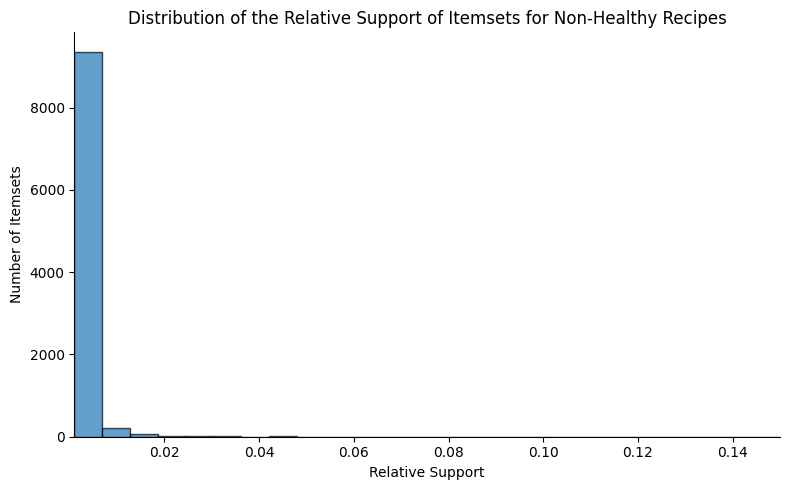

In [10]:
# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(itemset_freq['support'], bins=50, edgecolor='black', 
         alpha=0.7)
plt.title("Distribution of the Relative Support of Itemsets for Non-Healthy Recipes")
plt.xlabel("Relative Support")
plt.ylabel("Number of Itemsets")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# --- Adjust x-axis and layout ---
plt.xlim(0.001, 0.15)
plt.margins(x=0.02, y=0.05)
plt.tight_layout()
plt.savefig('figures/relsup_non_healthy.png', dpi=300)

plt.show()

count    32.000000
mean      0.643792
std       0.112405
min       0.504160
25%       0.555750
50%       0.591038
75%       0.765073
max       0.834059
dtype: float64


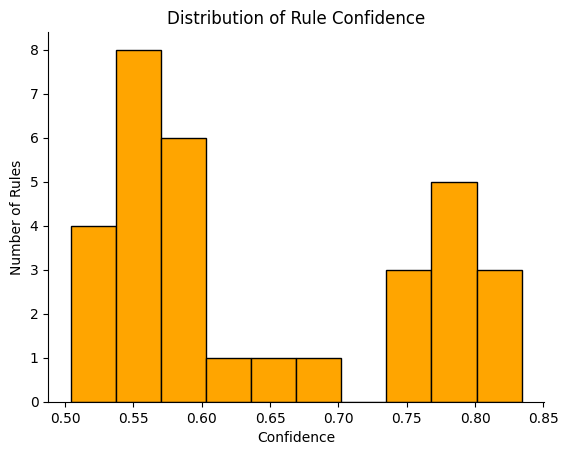

In [11]:
# Choose support threshold based on percentile 
min_support = 0.015

# Use your data-driven min_support
minsup_count = max(1, int(len(df) * min_support))
freq_items = pyfpgrowth.find_frequent_patterns(df_non_healthy['ingredients'].to_list(), 
minsup_count)

# Generate rules with a low min_conf to inspect distribution
rules = pyfpgrowth.generate_association_rules(freq_items, 0.5)

# Collect all confidence values
confidences = [conf for (_, (__, conf)) in rules.items()]

# Display stats and histogram
print(pd.Series(confidences).describe())

plt.hist(confidences, bins=10, color='orange', edgecolor = 'black')
plt.title("Distribution of Rule Confidence")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('figures/rules_non_healthy.png', dpi=300)
plt.show()


### Using best parameters

we chose minsupport = 0.01 using elbow method and will use min confidence = 0.79 since it captures the top quartile of high-quality rules for a strong rule zone

In [12]:
# --- Parameters ---
min_support = 0.015
min_confidence = 0.55

# --- Step 1: Compute minsup count ---
num_transactions = len(df_non_healthy['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(df_non_healthy['ingredients'].to_list(),
                                                  minsup_count)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and optionally lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Step 6: Display top 10 rules ---
top10_rules = lifted_rules
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules, 
                                                               start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


1. {'pepper', 'butter'} -> {'salt'} (confidence = 0.83, lift = 2.28)
2. {'all-purpose flour', 'baking soda'} -> {'salt'} (confidence = 0.81, lift = 2.23)
3. {'sugar', 'eggs', 'baking soda'} -> {'salt'} (confidence = 0.81, lift = 2.23)
4. {'onion', 'pepper'} -> {'salt'} (confidence = 0.81, lift = 2.22)
5. {'olive oil', 'pepper'} -> {'salt'} (confidence = 0.80, lift = 2.20)
6. {'baking powder', 'milk'} -> {'salt'} (confidence = 0.80, lift = 2.19)
7. {'eggs', 'baking soda'} -> {'salt'} (confidence = 0.80, lift = 2.18)
8. {'vanilla', 'baking soda'} -> {'salt'} (confidence = 0.79, lift = 2.16)
9. {'brown sugar', 'baking soda'} -> {'salt'} (confidence = 0.78, lift = 2.14)
10. {'sugar', 'baking powder'} -> {'salt'} (confidence = 0.78, lift = 2.13)
11. {'sugar', 'eggs', 'baking powder'} -> {'salt'} (confidence = 0.78, lift = 2.13)
12. {'egg', 'baking powder'} -> {'salt'} (confidence = 0.77, lift = 2.11)
13. {'sugar', 'flour', 'baking powder'} -> {'salt'} (confidence = 0.77, lift = 2.10)
14. {'

In [28]:
non_healthy_freq_df = (
    pd.DataFrame(list(freq_itemsets.items()), columns=["ingredients", "support"])
    .sort_values(by="support", ascending=False)
    .head(10)
)

non_healthy_freq_df['rel_support'] = non_healthy_freq_df['support'] / num_transactions
non_healthy_freq_df

,ingredients,support,rel_support
264,"(salt,)",68134,0.365430
262,"(butter,)",48934,0.262452
263,"(butter, salt)",22210,0.119121
261,"(salt, sugar)",17630,0.094557
255,"(eggs, salt)",16087,0.086281
205,"(pepper, salt)",15243,0.081754
236,"(flour, salt)",13535,0.072594
258,"(onion, salt)",13410,0.071923
253,"(butter, eggs)",13293,0.071296
259,"(butter, sugar)",13050,0.069992


## FIM all ingredients for healthy food filtered by tags


### Hyperparameter tune

In [15]:
# --- Prepare transactions (list of ingredient lists) ---
transactions = df_healthy['ingredients'].tolist()

# --- Set minimum support threshold ---
min_support = 0.001  # you can adjust this

# --- Compute absolute minimum support count ---
minsup_count = max(1, int(len(transactions) * min_support))

# --- Find frequent itemsets ---
patterns = pyfpgrowth.find_frequent_patterns(transactions, 
                                             minsup_count)

# --- Convert to DataFrame ---
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(df_healthy)

# --- Filter supports (just to zoom in) ---
itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

# --- Show summary statistics ---
print(itemset_freq['support'].describe())


count    11216.000000
mean         0.002298
std          0.005467
min          0.001018
25%          0.001173
50%          0.001461
75%          0.002102
max          0.389749
Name: support, dtype: float64


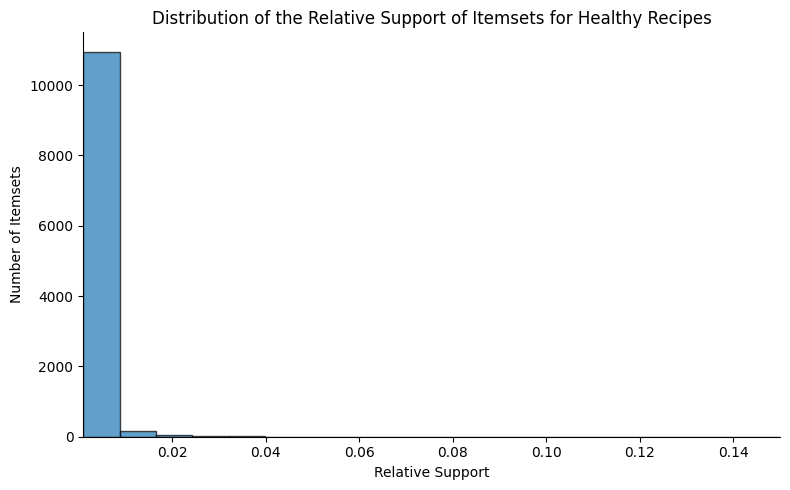

In [16]:
# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
plt.title("Distribution of the Relative Support of Itemsets for Healthy Recipes")
plt.xlabel("Relative Support")
plt.ylabel("Number of Itemsets")

# --- Adjust x-axis and layout ---
plt.xlim(0.001, 0.15)
plt.margins(x=0.02, y=0.05)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('figures/relsup_healthy.png', dpi=300)
plt.show()

count    43.000000
mean      0.670671
std       0.127509
min       0.500541
25%       0.550381
50%       0.659322
75%       0.778106
max       0.916168
dtype: float64


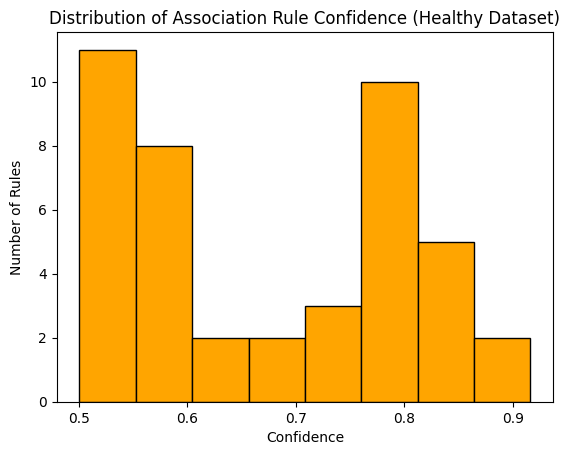

In [17]:
# --- Use the tuned or chosen min_support from Step 1 ---
min_support = 0.015  

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets for healthy recipes ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(), minsup_count
)

# --- Generate association rules with a LOW confidence threshold ---
# We start low (e.g., 0.5) to capture the full confidence distribution
healthy_rules=pyfpgrowth.generate_association_rules(healthy_freq_ingredients,
                                                      0.5)

# --- Extract all confidence values ---
confidences = [conf for (_, (__, conf)) in healthy_rules.items()]

# --- Show descriptive statistics of confidence distribution ---
print(pd.Series(confidences).describe())

# --- Plot histogram of confidence values ---
plt.hist(confidences, bins=8, color='orange', edgecolor='black')
plt.title("Distribution of Association Rule Confidence (Healthy Dataset)")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()


### Using Best Parameters

In [18]:
# --- Set tuned hyperparameters ---
min_support = 0.015
min_confidence = 0.58

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(),
    minsup_count
)

# --- Generate association rules ---
healthy_rules = pyfpgrowth.generate_association_rules(
    healthy_freq_ingredients,
    min_confidence
)

# --- Calculate support for each itemset ---
def get_support(itemset):
    """Return support (fraction of transactions)."""
    return healthy_freq_ingredients.get(itemset, 0) / len(df_healthy)


# --- Compute lift for each rule ---
lifted_rules = []
for antecedent, (consequent, confidence) in healthy_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # Avoid divide-by-zero errors
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_rules.append(
        (antecedent, consequent, confidence, lift)
    )

# --- Sort rules by confidence (and lift) descending ---
lifted_rules = sorted(
    lifted_rules,
    key=lambda x: (x[2], x[3]),
    reverse=True
)

top10_rules_lift = lifted_rules[:10]

# --- Display neatly ---
print("Top 10 Association Rules\n")

for i, (antecedent, consequent, confidence, lift) in enumerate(
    top10_rules_lift, start=1
):
    print(
        f"{i}. {set(antecedent)} -> {set(consequent)} "
        f"(confidence = {confidence:.2f}, lift = {lift:.2f})"
    )


Top 10 Association Rules

1. {'active dry yeast'} -> {'salt'} (confidence = 0.92, lift = 2.35)
2. {'warm water'} -> {'salt'} (confidence = 0.87, lift = 2.24)
3. {'olive oil', 'pepper'} -> {'salt'} (confidence = 0.86, lift = 2.20)
4. {'onion', 'pepper'} -> {'salt'} (confidence = 0.83, lift = 2.12)
5. {'butter', 'baking powder'} -> {'salt'} (confidence = 0.82, lift = 2.11)
6. {'sugar', 'all-purpose flour'} -> {'salt'} (confidence = 0.82, lift = 2.09)
7. {'baking powder', 'all-purpose flour'} -> {'salt'} (confidence = 0.81, lift = 2.09)
8. {'baking powder', 'milk'} -> {'salt'} (confidence = 0.79, lift = 2.03)
9. {'sugar', 'baking powder'} -> {'salt'} (confidence = 0.79, lift = 2.01)
10. {'sugar', 'flour', 'baking powder'} -> {'salt'} (confidence = 0.78, lift = 2.01)


In [ ]:
healthy_freq_df = (
    pd.DataFrame(list(healthy_freq_ingredients.items()), columns=["ingredients", "support"])
    .sort_values(by="support", ascending=False)
    .head(10)
)

healthy_freq_df['rel_support'] = healthy_freq_df['support'] / len(df_healthy)
healthy_freq_df


,ingredients,support,rel_support
226,"(salt,)",17612,0.389749
224,"(sugar,)",10060,0.222625
225,"(salt, sugar)",5078,0.112375
223,"(salt, water)",4458,0.098655
212,"(butter, salt)",3379,0.074776
217,"(olive oil, salt)",3240,0.071700
220,"(onion, salt)",3237,0.071634
221,"(sugar, water)",2939,0.065039
200,"(flour, salt)",2887,0.063889
127,"(honey,)",2649,0.058622


## Compare if the frequent ingredients in all and healthy-only recipes are similar

We use the Jaccard index as a way to measure similarity. Since the similarity is 0.45 between the frequent ingredient itemsets of all recipes and healthy-only recipes, this indicates that there is only a moderate overlap between the two groups. In other words, nearly half of the commonly used ingredients in healthy recipes are not the same as those in the general recipe population. This suggests that healthy recipes rely on a distinct set of ingredients, reflecting meaningful differences in ingredient composition and dietary choices.

In [20]:
def jaccard_index(list1, list2):
    """Compute the Jaccard index between two lists."""
    set1 = set(list1)
    set2 = set(list2)

    # Avoid division by zero when both lists are empty
    if not set1 and not set2:
        return 0

    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union


jaccard_index(
    list(freq_itemsets.keys()),
    list(healthy_freq_ingredients.keys())
)


0.45132743362831856

In [51]:
# Convert keys to sets
nonhealthy_sets = set(freq_itemsets.keys())
healthy_sets = set(healthy_freq_ingredients.keys())

# Set difference: healthy but not in non-healthy
unique_healthy_sets = healthy_sets - nonhealthy_sets

# Filter healthy_freq_ingredients to only these unique sets
unique_healthy_dict = {k: healthy_freq_ingredients[k] for k in unique_healthy_sets}

# Convert to DataFrame for easier inspection
import pandas as pd

unique_healthy_df = pd.DataFrame(
    list(unique_healthy_dict.items()), 
    columns=['ingredients', 'support']
)

# Calculate relative support
total_healthy_recipes = sum(healthy_freq_ingredients.values())  # or total number of healthy recipes
unique_healthy_df['rel_support'] = unique_healthy_df['support'] / len(df_healthy)

# Sort by support to see the most frequent unique healthy itemsets
unique_healthy_df = unique_healthy_df.sort_values(by='support', ascending=False)

unique_healthy_df.head(10)


,ingredients,support,rel_support
7,"(sugar,)",10060,0.222625
34,"(vegetable oil,)",2586,0.057228
17,"(flour, sugar)",2124,0.047004
67,"(milk, sugar)",1770,0.039170
1,"(eggs, sugar)",1576,0.034877
68,"(baking powder, baking soda)",1328,0.029388
9,"(baking soda, sugar)",1216,0.026910
62,"(all-purpose flour, baking powder)",1159,0.025648
4,"(whole wheat flour,)",1151,0.025471
59,"(all-purpose flour, sugar)",1141,0.025250


### Robustness

In [41]:
def test_itemset_robustness_pyfpgrowth(
    transactions,
    min_support_ratio=0.04,
    n_shuffles=5,
    random_state=42
):
    """
    Test robustness of frequent itemsets to shuffling using pyfpgrowth.

    Args:
        transactions (list of lists): e.g. [['milk', 'bread'], ['beer', ...]]
        min_support_ratio (float): Fraction of total transactions for min_support.
        n_shuffles (int): Number of shuffle iterations.
        random_state (int): Base seed for reproducibility.

    Returns:
        pd.DataFrame: Overlap ratios across runs.
    """
    np.random.seed(random_state)
    n_transactions = len(transactions)
    min_support = int(np.ceil(min_support_ratio * n_transactions))

    # --- Base run ---
    base_patterns = pyfpgrowth.find_frequent_patterns(
        transactions,
        min_support
    )
    base_itemsets = set(base_patterns.keys())

    overlaps = []

    # --- Shuffled runs ---
    for i in range(n_shuffles):
        shuffled = transactions.copy()
        np.random.shuffle(shuffled)

        patterns = pyfpgrowth.find_frequent_patterns(
            shuffled,
            min_support
        )
        shuffled_itemsets = set(patterns.keys())

        # Compute overlap
        if base_itemsets:
            overlap = (
                len(base_itemsets & shuffled_itemsets) / len(base_itemsets)
            )
        else:
            overlap = np.nan

        overlaps.append(overlap)

    # --- Summary DataFrame ---
    result = pd.DataFrame({
        "shuffle_run": range(1, n_shuffles + 1),
        "overlap_with_base": overlaps
    })

    print("Average overlap with base:", np.mean(overlaps))
    return result


# Example usage
robustness_results = test_itemset_robustness_pyfpgrowth(
    df_healthy["ingredients"].to_list(),
    min_support_ratio=0.01,
    n_shuffles=5
)
robustness_results


Average overlap with base: 1.0


,shuffle_run,overlap_with_base
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


In [42]:
robustness_non_healthy_results = test_itemset_robustness_pyfpgrowth(
    df_non_healthy["ingredients"].to_list(),
    min_support_ratio=0.01,
    n_shuffles=5
)
robustness_non_healthy_results

Average overlap with base: 1.0


,shuffle_run,overlap_with_base
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


In [22]:
from collections import defaultdict


def estimate_coefficients_algorithm1(X, C, supports):
    """
    Implementation of Algorithm 1: Estimate coefficients of the polynomial
    given an itemset X, a set of frequent closed itemsets C, and their
    supports.

    Parameters
    ----------
    X : frozenset
        Target itemset.
    C : list of frozenset
        List of frequent closed itemsets.
    supports : dict
        Mapping of itemset (frozenset) -> support (count or ratio).

    Returns
    -------
    a : dict
        Mapping from integer k -> coefficient a_k.
    """

    # Step 1. Ensure X is in C
    if X not in C:
        C = C + [X]
        supports[X] = supports.get(X, 0)

    # Step 2. Select itemsets in C that contain X
    C_X = [Y for Y in C if X.issubset(Y)]

    # Step 3. Order sets by subset relation (by size ascending)
    C_X = sorted(C_X, key=lambda s: len(s))

    # Step 4. Initialize
    e = defaultdict(float)
    e[(X, X)] = 1.0
    a = defaultdict(float)

    # Step 5–8
    for Y in C_X:
        # Step 6. e(Y, X) = -Σ e(Z, X) for all Z⊂Y and X⊆Z
        if Y != X:
            subset_sum = sum(
                e.get((Z, X), 0)
                for Z in C_X
                if X.issubset(Z) and Z.issubset(Y) and Z != Y
            )
            e[(Y, X)] = -subset_sum

        # Step 7. k = sp(X) - sp(Y)
        k = supports.get(X, 0) - supports.get(Y, 0)

        # Step 8. a_k += e(Y, X)
        a[k] += e[(Y, X)]

    return dict(a)

In [ ]:
patterns = pyfpgrowth.find_frequent_patterns(
    df_healthy["ingredients"].to_list(),
    minsup_count
)

C = [frozenset(p) for p in patterns.keys()]
supports = {frozenset(p): v for p, v in patterns.items()}

X = frozenset(['salt'])  # choose any base itemset
coeffs = estimate_coefficients_algorithm1(X, C, supports)
coeffs

In [ ]:
patterns = pyfpgrowth.find_frequent_patterns(
    df_non_healthy["ingredients"].to_list(),
    minsup_count
)

C = [frozenset(p) for p in patterns.keys()]
supports = {frozenset(p): v for p, v in patterns.items()}

X = frozenset(['salt'])  # choose any base itemset
coeffs = estimate_coefficients_algorithm1(X, C, supports)
coeffs